# How to Estimate Value at Risk with Amplitude Estimation

### A hands-on notebook for my thesis track (quantum computing in finance)

This notebook sits at the intersection of **market risk** and **Quantum Amplitude Estimation (QAE)**.
The goal is didactic: start from a concrete portfolio, compute **Value at Risk (VaR)** the classical way,
then show *why* VaR can be rewritten as a **probability estimation** problem — exactly the problem QAE
was invented to accelerate (Brassard et al.; applications in finance by Rebentrost, Woerner & Egger,
Stamatopoulos, Goldman Sachs market-risk resource estimates, …).

**Roadmap**

1. What VaR means, in words and in formulas
2. A numerical portfolio: simulate P&L scenarios
3. Classical VaR from the empirical quantile (Monte Carlo)
4. Reframe VaR as "find the threshold whose CDF equals $\alpha$"
5. Amplitude Estimation in one picture: from Bernoulli events to a quadratic speedup
6. Numerical QAE-style estimator vs classical Monte Carlo
7. Binary search + AE: reconstruct VaR from probability estimates
8. Charts, sanity checks, and what this does *not* yet prove on real hardware

> Related files in this repo:
> - `../tesi/01_quantum_amplitude_estimation.py` — ideal QAE vs MC error scaling
> - `00_Paper_study/02_amplitude_estimation.ipynb` — AE operators $A$ and $Q$ step by step
> - `../tesi/papers/L2B_risk/L2B_02_goldman_market_risk_2022.py` — VaR/CVaR toy demo


## 0. Setup

We stay inside `.venv-quantum`: `numpy`, `scipy`, `matplotlib`. Qiskit is optional —
the core numerical story of this notebook does **not** need a quantum simulator.


In [2]:
import sys

try:
    sys.stdout.reconfigure(encoding="utf-8")
except (AttributeError, ValueError):
    pass

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({
    "figure.figsize": (9, 4.8),
    "axes.grid": True,
    "grid.alpha": 0.28,
    "font.size": 11,
    "axes.titlesize": 13,
})

rng = np.random.default_rng(7)

try:
    import qiskit  # noqa: F401
    import qiskit_aer  # noqa: F401
    HAS_QISKIT = True
except ImportError:
    HAS_QISKIT = False

print(f"numpy {np.__version__}  |  Qiskit available: {HAS_QISKIT}")


numpy 2.5.0  |  Qiskit available: True


## 1. What is Value at Risk?

Fix a confidence level $\alpha$ (typical choices: 95% or 99%) and a time horizon
(one day, ten days, …). Let $L$ be the **loss** of the portfolio over that horizon
(positive $L$ = we lose money).

$$
\mathrm{VaR}_\alpha(L) \;=\; \inf\big\{\,\ell \in \mathbb{R} :\; \mathbb{P}(L \leq \ell) \ge \alpha\,\big\}.
$$

In plain English: **VaR$_\alpha$ is the smallest loss threshold such that the probability
of losing *at most* that amount is at least $\alpha$**. Equivalently, with probability
$1-\alpha$ the loss exceeds VaR — those are the **tail** events risk managers care about.

Two remarks that matter for coding:

1. Banks often work with **P&L** $= -L$ (profit positive). Then 95% VaR is minus the
   5th percentile of the P&L distribution.
2. Estimating a **quantile in the far tail** is statistically expensive: rare events,
   so classical Monte Carlo needs *many* scenarios for a tight confidence interval.
   That cost is exactly why people look at QAE.


## 2. Numerical example: a small equity portfolio

We build a toy 3-asset portfolio under a multivariate Gaussian daily-return model
(the same spirit as linear VaR / parametric risk engines — deliberately simple so the
quantum part stays readable).

| Asset | Weight | Annual vol | Notes |
|-------|--------|------------|-------|
| A (equity) | 50% | 20% | |
| B (equity) | 30% | 25% | correlated with A |
| C (bond-like) | 20% | 5% | low vol, weak corr |

We simulate many **one-day** P&L scenarios, then convert to losses $L = -\mathrm{P\&L}$.


In [3]:
# --- Portfolio parameters -------------------------------------------------
# Think of this as a tiny risk book: three risk factors, one day horizon.
notional = 1_000_000.0          # portfolio value in currency units
weights = np.array([0.50, 0.30, 0.20])
ann_vol = np.array([0.20, 0.25, 0.05])
# Daily vols from annual (252 trading days) — sqrt-time scaling
daily_vol = ann_vol / np.sqrt(252)

# Correlation matrix (symmetric, positive semi-definite)
corr = np.array([
    [1.00, 0.60, 0.10],
    [0.60, 1.00, 0.05],
    [0.10, 0.05, 1.00],
])
cov = np.outer(daily_vol, daily_vol) * corr   # daily covariance of returns

# Cholesky: turn independent Gaussians into correlated returns
chol = np.linalg.cholesky(cov)

N_SCENARIOS = 80_000
Z = rng.standard_normal((N_SCENARIOS, 3))
returns = Z @ chol.T                           # correlated daily returns
pnl = notional * (returns @ weights)           # portfolio P&L
loss = -pnl                                    # loss convention: positive = bad

print(f"Scenarios: {N_SCENARIOS:,}")
print(f"Mean P&L:  {pnl.mean():,.2f}")
print(f"Std  P&L:  {pnl.std(ddof=1):,.2f}")
print(f"Min / Max P&L: {pnl.min():,.2f}  /  {pnl.max():,.2f}")


Scenarios: 80,000
Mean P&L:  -0.34
Std  P&L:  9,919.60
Min / Max P&L: -39,119.65  /  41,228.55


## 3. Classical VaR from the empirical quantile

For $\alpha = 0.95$, the classical Monte Carlo estimator is simply:

$$
\widehat{\mathrm{VaR}}_{0.95} = -\,\mathrm{quantile}(\mathrm{P\&L},\, 0.05)
= \mathrm{quantile}(L,\, 0.95).
$$

We also compute a quick **analytic Gaussian VaR** (delta-normal) as a sanity check:
$\mathrm{VaR}_\alpha \approx \sigma_p\,\Phi^{-1}(\alpha)$ for zero-mean P&L, where
$\sigma_p$ is the portfolio daily volatility in currency units.


Confidence level alpha = 95%
Monte Carlo VaR_95      = 16,310.37
  (via P&L percentile) = 16,310.37
Analytic Gaussian VaR  = 16,383.13
Empirical P(L > VaR)   = 0.0500   (target ~ 0.05)


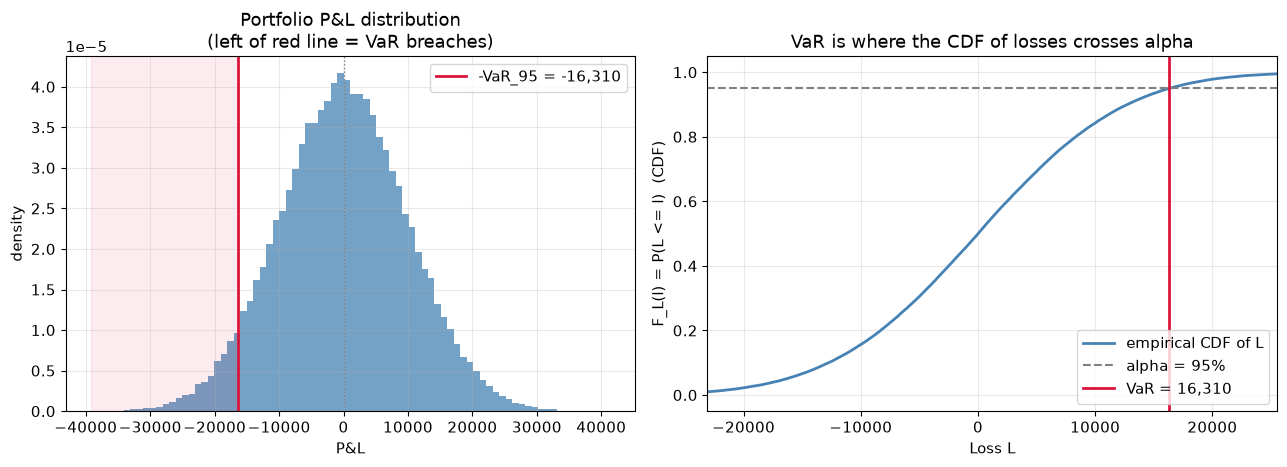

In [4]:
ALPHA = 0.95
tail = 1.0 - ALPHA   # 0.05

var_mc = float(np.quantile(loss, ALPHA))                 # empirical VaR
var_mc_pnl = -float(np.quantile(pnl, tail))              # same via P&L
sigma_p = float(np.sqrt(weights @ cov @ weights) * notional)
var_analytic = float(sigma_p * stats.norm.ppf(ALPHA))    # Gaussian VaR

# Empirical breach rate at the estimated VaR (should be ~ 5%)
breach_rate = float(np.mean(loss > var_mc))

print("=" * 60)
print(f"Confidence level alpha = {ALPHA:.0%}")
print(f"Monte Carlo VaR_95      = {var_mc:,.2f}")
print(f"  (via P&L percentile) = {var_mc_pnl:,.2f}")
print(f"Analytic Gaussian VaR  = {var_analytic:,.2f}")
print(f"Empirical P(L > VaR)   = {breach_rate:.4f}   (target ~ {tail:.2f})")
print("=" * 60)

# --- Chart 1: P&L histogram + VaR line ------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

ax = axes[0]
ax.hist(pnl, bins=80, density=True, color="steelblue", alpha=0.75, edgecolor="none")
ax.axvline(-var_mc, color="crimson", lw=2,
           label=f"-VaR_{int(ALPHA*100)} = {-var_mc:,.0f}")
ax.axvline(0, color="gray", ls=":", lw=1)
# shade the left tail (bad outcomes) for visual emphasis
yl = ax.get_ylim()
ax.axvspan(pnl.min(), -var_mc, color="crimson", alpha=0.08)
ax.set_ylim(yl)
ax.set_xlabel("P&L")
ax.set_ylabel("density")
ax.set_title("Portfolio P&L distribution\n(left of red line = VaR breaches)")
ax.legend()

ax = axes[1]
# Empirical CDF of losses — VaR is where this curve crosses alpha
sorted_loss = np.sort(loss)
cdf = np.arange(1, len(sorted_loss) + 1) / len(sorted_loss)
ax.plot(sorted_loss, cdf, lw=2, color="steelblue", label="empirical CDF of L")
ax.axhline(ALPHA, color="gray", ls="--", label=f"alpha = {int(ALPHA*100)}%")
ax.axvline(var_mc, color="crimson", lw=2, label=f"VaR = {var_mc:,.0f}")
ax.set_xlabel("Loss L")
ax.set_ylabel("F_L(l) = P(L <= l)  (CDF)")
ax.set_title("VaR is where the CDF of losses crosses alpha")
ax.legend(loc="lower right")
ax.set_xlim(sorted_loss[int(0.01 * len(sorted_loss))],
            sorted_loss[int(0.995 * len(sorted_loss))])

plt.tight_layout()
plt.show()


### How to read these two plots

- **Left.** Most days the P&L sits near zero. The red vertical line marks $-$VaR:
  only about 5% of the mass lies to its *left* (severe losses). If tomorrow's P&L
  falls left of that line, we call it a **VaR exception** (used later in backtesting).
- **Right.** Same information as a CDF of *losses*. Walk along the horizontal axis
  until the cumulative probability hits 95%: that loss level *is* VaR.
  This picture is the key that unlocks Amplitude Estimation.


## 4. Reframing VaR as a probability estimation problem

Pick any candidate threshold $\ell$. Define the **indicator** (Bernoulli) random variable

$$
X_\ell \;=\; \mathbf{1}_{\{L \leq \ell\}} \;\in\; \{0,1\},
\qquad
a(\ell) \;=\; \mathbb{E}[X_\ell] \;=\; \mathbb{P}(L \leq \ell).
$$

Then VaR is the root of the monotone equation

$$
a(\ell) \;=\; \alpha.
$$

Classically we estimate $a(\ell)$ by the sample mean of indicators (Monte Carlo).
**Quantum Amplitude Estimation** estimates the same number $a(\ell)$, but with a
different query complexity.

This is the bridge used in the quantum-risk literature:

> *quantile estimation*  →  *binary search on $\ell$*  +  *amplitude estimation of $a(\ell)$*.


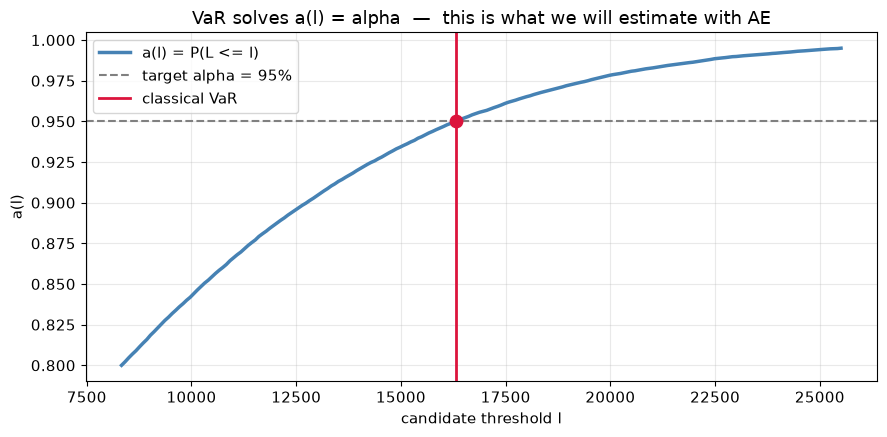

At the classical VaR threshold:
  a(VaR) = P(L <= VaR) = 0.9500  (should be ~ 0.95)


In [5]:
# Visualize a(ell) = P(L <= ell) and mark VaR — the equation we will solve with AE
ell_grid = np.linspace(np.quantile(loss, 0.80), np.quantile(loss, 0.995), 200)
a_ell = np.array([np.mean(loss <= ell) for ell in ell_grid])

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(ell_grid, a_ell, lw=2.5, color="steelblue", label="a(l) = P(L <= l)")
ax.axhline(ALPHA, color="gray", ls="--", lw=1.5, label=f"target alpha = {int(ALPHA*100)}%")
ax.axvline(var_mc, color="crimson", lw=2, label="classical VaR")
ax.scatter([var_mc], [ALPHA], color="crimson", s=80, zorder=5)
ax.set_xlabel("candidate threshold l")
ax.set_ylabel("a(l)")
ax.set_title("VaR solves a(l) = alpha  —  this is what we will estimate with AE")
ax.legend()
plt.tight_layout()
plt.show()

print("At the classical VaR threshold:")
print(f"  a(VaR) = P(L <= VaR) = {np.mean(loss <= var_mc):.4f}  (should be ~ {ALPHA})")


## 5. Amplitude Estimation in one picture

Suppose we can prepare a quantum state

$$
A|0\rangle \;=\; \sqrt{1-a}\,|0\rangle_g|\psi_0\rangle \;+\; \sqrt{a}\,|1\rangle_g|\psi_1\rangle,
$$

where the ancilla bit $g$ is $|1\rangle$ exactly on the "marked" subspace
(here: scenarios with $L \leq \ell$). Then $a$ is an **amplitude squared**, and
Brassard's QAE estimates it with error

$$
\varepsilon_{\mathrm{QAE}} \;=\; \mathcal{O}\!\left(\frac{1}{M}\right)
$$

using $M$ applications of the Grover-like operator $Q$, versus the classical Monte Carlo

$$
\varepsilon_{\mathrm{MC}} \;=\; \mathcal{O}\!\left(\frac{1}{\sqrt{N}}\right)
$$

with $N$ samples. That is the famous **quadratic speedup**.

In this notebook we will *not* compile a full risk oracle on hardware. Instead we:

1. treat each scenario's indicator $X_\ell$ as a Bernoulli with success probability $a(\ell)$;
2. simulate an **ideal QAE measurement** whose statistical error follows the Brassard
   bound $\pi/(2M)$ (same modelling choice as `01_quantum_amplitude_estimation.py`);
3. compare it, budget-for-budget, to classical sampling of the same indicators.

This is the right mental model before you open Qiskit Circuits: first understand *what*
is being estimated and *why* the sample complexity changes.


In [6]:
def classical_estimate_a(indicators: np.ndarray, n_samples: int, rng) -> float:
    '''Monte Carlo estimate of a = E[X] from a pool of 0/1 indicators.'''
    idx = rng.integers(0, len(indicators), size=n_samples)
    return float(indicators[idx].mean())


def ideal_qae_estimate_a(a_true: float, M: int, rng) -> float:
    '''
    Idealized QAE estimator (Brassard-style).

    Canonical QAE effectively learns the angle theta = arcsin(sqrt(a)).
    With M Grover applications the phase resolution is ~ pi/M, which maps
    back to an error of order pi/(2*M) on a itself.

    We model one shot of that process as: perturb theta by N(0, pi/(2*M)),
    then return sin^2(theta_hat), clipped to [0, 1].
    This captures the 1/M scaling without building full QPE.
    '''
    theta = np.arcsin(np.sqrt(np.clip(a_true, 0.0, 1.0)))
    theta_hat = theta + rng.normal(0.0, np.pi / (2 * M))
    theta_hat = np.clip(theta_hat, 0.0, 0.5 * np.pi)
    return float(np.sin(theta_hat) ** 2)


# Pick the true a at the classical VaR (should be ~ alpha)
indicators_at_var = (loss <= var_mc).astype(float)
a_true = float(indicators_at_var.mean())
print(f"True a(VaR) from full scenario set = {a_true:.6f}")

# One illustrative estimate at a modest budget
M_demo = 64
a_qae_demo = ideal_qae_estimate_a(a_true, M_demo, rng)
a_mc_demo = classical_estimate_a(indicators_at_var, n_samples=M_demo, rng=rng)
print(f"With budget M = {M_demo}:")
print(f"  classical MC estimate = {a_mc_demo:.6f}   |error| = {abs(a_mc_demo - a_true):.6f}")
print(f"  ideal QAE estimate    = {a_qae_demo:.6f}   |error| = {abs(a_qae_demo - a_true):.6f}")


True a(VaR) from full scenario set = 0.950000
With budget M = 64:
  classical MC estimate = 0.953125   |error| = 0.003125
  ideal QAE estimate    = 0.926092   |error| = 0.023908


## 6. Error scaling: Monte Carlo vs ideal QAE

We repeat the estimation of $a(\mathrm{VaR})$ many times for increasing budgets $M$,
and plot the **mean absolute error**. You should see MC fall like $1/\sqrt{M}$ and
ideal QAE like $1/M$.


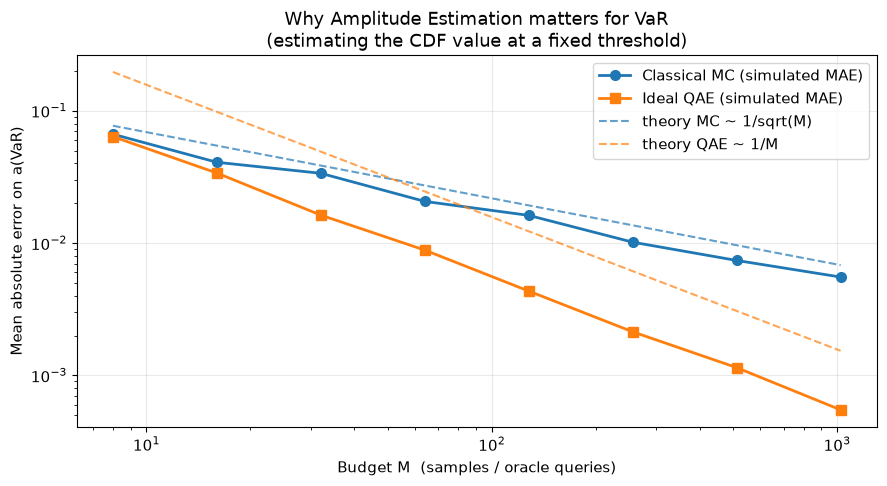

MAE table:
     M          MC         QAE    MC/QAE
     8     0.06650     0.06377      1.04x
    16     0.04080     0.03383      1.21x
    32     0.03367     0.01626      2.07x
    64     0.02065     0.00885      2.33x
   128     0.01619     0.00434      3.73x
   256     0.01016     0.00213      4.76x
   512     0.00739     0.00114      6.46x
  1024     0.00554     0.00055     10.09x


In [7]:
budgets = np.array([8, 16, 32, 64, 128, 256, 512, 1024])
N_TRIALS = 250

mc_mae = []
qae_mae = []

for M in budgets:
    mc_errs = []
    qae_errs = []
    for _ in range(N_TRIALS):
        a_hat_mc = classical_estimate_a(indicators_at_var, int(M), rng)
        a_hat_qae = ideal_qae_estimate_a(a_true, int(M), rng)
        mc_errs.append(abs(a_hat_mc - a_true))
        qae_errs.append(abs(a_hat_qae - a_true))
    mc_mae.append(np.mean(mc_errs))
    qae_mae.append(np.mean(qae_errs))

mc_mae = np.array(mc_mae)
qae_mae = np.array(qae_mae)

# Theoretical reference curves
mc_theory = np.sqrt(a_true * (1 - a_true) / budgets)          # Bernoulli stderr
qae_theory = np.pi / (2 * budgets)                             # Brassard-style

fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(budgets, mc_mae, "o-", lw=2, ms=7, label="Classical MC (simulated MAE)")
ax.loglog(budgets, qae_mae, "s-", lw=2, ms=7, label="Ideal QAE (simulated MAE)")
ax.loglog(budgets, mc_theory, "--", color="C0", alpha=0.7, label="theory MC ~ 1/sqrt(M)")
ax.loglog(budgets, qae_theory, "--", color="C1", alpha=0.7, label="theory QAE ~ 1/M")
ax.set_xlabel("Budget M  (samples / oracle queries)")
ax.set_ylabel("Mean absolute error on a(VaR)")
ax.set_title("Why Amplitude Estimation matters for VaR\n"
             "(estimating the CDF value at a fixed threshold)")
ax.legend()
plt.tight_layout()
plt.show()

print("MAE table:")
print(f"{'M':>6}  {'MC':>10}  {'QAE':>10}  {'MC/QAE':>8}")
for M, mc, qae in zip(budgets, mc_mae, qae_mae):
    ratio = mc / max(qae, 1e-15)
    print(f"{M:6d}  {mc:10.5f}  {qae:10.5f}  {ratio:8.2f}x")


### Reading the log–log plot

- Both curves go down as the budget grows — more queries, better estimate. Good.
- The **slope** is what matters: classical Monte Carlo is shallower ($\sim M^{-1/2}$),
  ideal QAE is steeper ($\sim M^{-1}$).
- On a risk desk the quantity $a(\ell)$ is queried *inside a search* over $\ell$
  (next section). A quadratic saving on each CDF evaluation compounds into a cheaper VaR.

Caveat (honest thesis tone): the orange curve is an **idealized** model of QAE.
Real circuits pay for state preparation, oracle depth, and decoherence. The plot is
the *complexity-theoretic* promise, not a claim that a bank can run this tomorrow.


## 7. Recovering VaR: binary search + Amplitude Estimation

Algorithm (quantum-risk textbook pattern):

1. Bracket the loss: $\ell_{\min} < \mathrm{VaR} < \ell_{\max}$.
2. While the bracket is wider than a tolerance $\delta$:
   - set $\ell \leftarrow (\ell_{\min}+\ell_{\max})/2$;
   - estimate $\hat a(\ell)$ with AE (budget $M$);
   - if $\hat a(\ell) < \alpha$ then VaR is larger → $\ell_{\min}\leftarrow\ell$;
     else $\ell_{\max}\leftarrow\ell$.
3. Return the midpoint as $\widehat{\mathrm{VaR}}$.

We run this twice: once with classical MC estimates of $a(\ell)$, once with ideal QAE,
**same budget $M$ per CDF evaluation**, and compare the final VaR error against the
full-sample classical VaR from Section 3 (our ground truth proxy).


In [8]:
def estimate_var_by_search(
    loss_pool: np.ndarray,
    alpha: float,
    budget_M: int,
    mode: str,          # "mc" or "qae"
    rng,
    tol: float = 50.0,  # currency units
    max_iter: int = 40,
):
    '''
    Binary search for VaR using either MC or ideal-QAE estimates of a(ell).

    Returns (var_hat, history) where history records
    (midpoint, a_hat, a_true_at_mid) at each iteration — useful for the charts.
    '''
    lo = float(np.quantile(loss_pool, 0.85))
    hi = float(np.quantile(loss_pool, 0.995))
    history = []

    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)
        # True a for this threshold from the full pool (oracle knowledge for the sim)
        a_true_mid = float(np.mean(loss_pool <= mid))
        indicators = (loss_pool <= mid).astype(float)

        if mode == "mc":
            a_hat = classical_estimate_a(indicators, budget_M, rng)
        elif mode == "qae":
            a_hat = ideal_qae_estimate_a(a_true_mid, budget_M, rng)
        else:
            raise ValueError(mode)

        history.append((mid, a_hat, a_true_mid))

        # Monotone search: if CDF estimate is below alpha, VaR is to the right
        if a_hat < alpha:
            lo = mid
        else:
            hi = mid

        if hi - lo < tol:
            break

    return 0.5 * (lo + hi), history


BUDGET = 128
var_mc_search, hist_mc = estimate_var_by_search(loss, ALPHA, BUDGET, "mc", rng)
var_qae_search, hist_qae = estimate_var_by_search(loss, ALPHA, BUDGET, "qae", rng)

print(f"Ground-truth proxy (full-sample quantile) VaR = {var_mc:,.2f}")
print(f"Binary search + MC  (M={BUDGET}/eval)  VaR    = {var_mc_search:,.2f}   "
      f"|err| = {abs(var_mc_search - var_mc):,.2f}")
print(f"Binary search + QAE (M={BUDGET}/eval)  VaR    = {var_qae_search:,.2f}   "
      f"|err| = {abs(var_qae_search - var_mc):,.2f}")
print(f"Iterations MC={len(hist_mc)}, QAE={len(hist_qae)}")


Ground-truth proxy (full-sample quantile) VaR = 16,310.37
Binary search + MC  (M=128/eval)  VaR    = 17,911.74   |err| = 1,601.37
Binary search + QAE (M=128/eval)  VaR    = 16,366.20   |err| = 55.83
Iterations MC=9, QAE=9


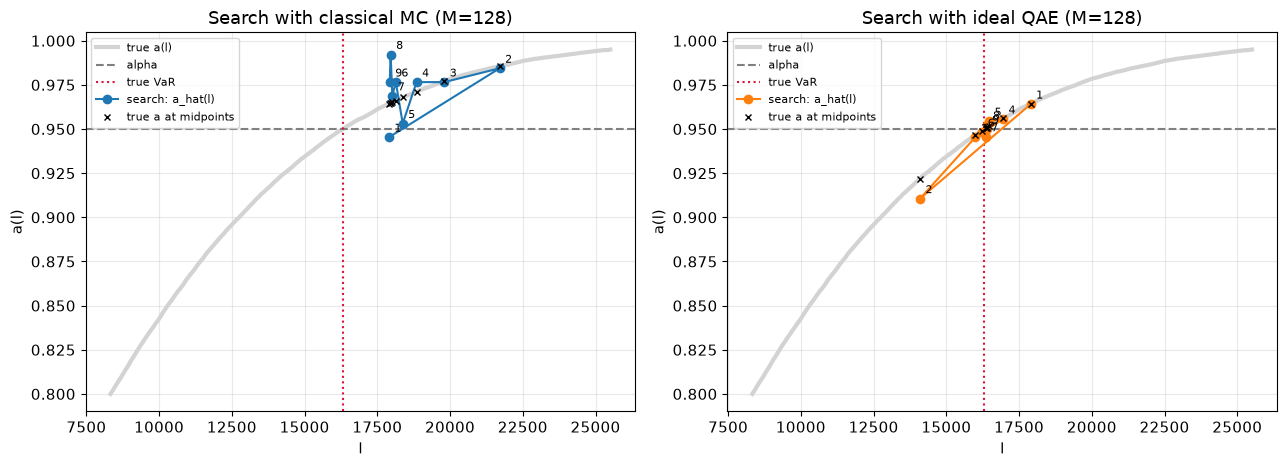

In [9]:
# --- Chart: search trajectories in (ell, a) space ---------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))


def plot_search(ax, history, title, color):
    mids = np.array([h[0] for h in history])
    a_hats = np.array([h[1] for h in history])
    a_trues = np.array([h[2] for h in history])
    ax.plot(ell_grid, a_ell, color="lightgray", lw=3, label="true a(l)")
    ax.axhline(ALPHA, color="gray", ls="--", label="alpha")
    ax.axvline(var_mc, color="crimson", ls=":", lw=1.5, label="true VaR")
    ax.plot(mids, a_hats, "o-", color=color, lw=1.5, ms=6, label="search: a_hat(l)")
    ax.plot(mids, a_trues, "x", color="black", ms=5, label="true a at midpoints")
    for i, (m, ah) in enumerate(zip(mids, a_hats)):
        ax.annotate(str(i + 1), (m, ah), textcoords="offset points",
                    xytext=(4, 4), fontsize=8)
    ax.set_xlabel("l")
    ax.set_ylabel("a(l)")
    ax.set_title(title)
    ax.legend(fontsize=8)


plot_search(axes[0], hist_mc, f"Search with classical MC (M={BUDGET})", "C0")
plot_search(axes[1], hist_qae, f"Search with ideal QAE (M={BUDGET})", "C1")
plt.tight_layout()
plt.show()


### What the search charts are telling you

Each numbered point is one CDF evaluation inside the binary search.
The gray curve is the true $a(\ell)$; the colored path is what the *estimator* saw.

- When $\hat a$ is noisy (classical MC at small $M$), the search can **mis-step**:
  a threshold that is actually below VaR might look above $\alpha$, or vice versa.
- Ideal QAE, at the same $M$, hugs the true $a(\ell)$ more tightly, so the search
  closes on the red VaR line more reliably.

Try changing `BUDGET` (e.g. 32 vs 512) and re-running the two cells above: the
gap between the two methods shrinks or widens exactly as the scaling plot predicts.


## 8. Distribution of VaR estimation error (many independent runs)

One run is not enough. We repeat the whole search many times and histogram the
absolute error $|\widehat{\mathrm{VaR}} - \mathrm{VaR}_{\mathrm{true}}|$.


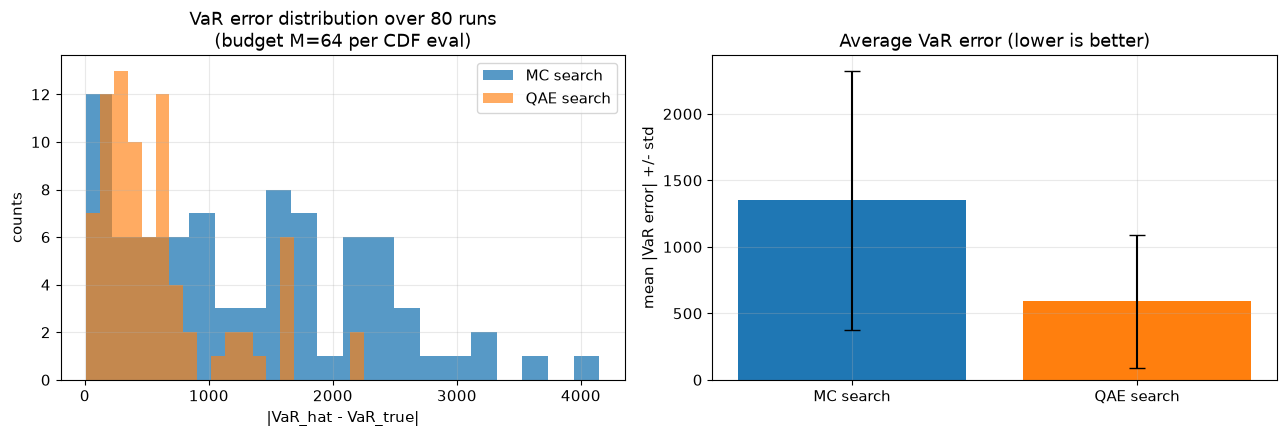

Mean |VaR error|  MC  = 1,351.20  ± 974.81
Mean |VaR error|  QAE = 591.39  ± 500.15
Ratio (MC / QAE)      = 2.28x


In [10]:
N_RUNS = 80
BUDGET_CMP = 64

err_mc_runs = []
err_qae_runs = []
for _ in range(N_RUNS):
    v_mc, _ = estimate_var_by_search(loss, ALPHA, BUDGET_CMP, "mc", rng, tol=80.0)
    v_qae, _ = estimate_var_by_search(loss, ALPHA, BUDGET_CMP, "qae", rng, tol=80.0)
    err_mc_runs.append(abs(v_mc - var_mc))
    err_qae_runs.append(abs(v_qae - var_mc))

err_mc_runs = np.array(err_mc_runs)
err_qae_runs = np.array(err_qae_runs)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.hist(err_mc_runs, bins=20, alpha=0.75, color="C0", label="MC search")
ax.hist(err_qae_runs, bins=20, alpha=0.65, color="C1", label="QAE search")
ax.set_xlabel("|VaR_hat - VaR_true|")
ax.set_ylabel("counts")
ax.set_title(f"VaR error distribution over {N_RUNS} runs\n"
             f"(budget M={BUDGET_CMP} per CDF eval)")
ax.legend()

ax = axes[1]
ax.bar(
    ["MC search", "QAE search"],
    [err_mc_runs.mean(), err_qae_runs.mean()],
    yerr=[err_mc_runs.std(), err_qae_runs.std()],
    color=["C0", "C1"],
    capsize=6,
)
ax.set_ylabel("mean |VaR error| +/- std")
ax.set_title("Average VaR error (lower is better)")

plt.tight_layout()
plt.show()

print(f"Mean |VaR error|  MC  = {err_mc_runs.mean():,.2f}  ± {err_mc_runs.std():,.2f}")
print(f"Mean |VaR error|  QAE = {err_qae_runs.mean():,.2f}  ± {err_qae_runs.std():,.2f}")
print(f"Ratio (MC / QAE)      = {err_mc_runs.mean() / max(err_qae_runs.mean(), 1e-12):.2f}x")


## 9. Bonus: a tiny Qiskit Bernoulli Amplitude Estimation (optional)

If Qiskit is installed, we encode a **single Bernoulli** with success probability
$a = P(L \leq \mathrm{VaR})$ into one qubit and run a small canonical-style AE by
phase estimation on the Grover iterate. This is *not* a full risk oracle — it is
the pedagogical circuit for "estimate $a$" once $a$ is known classically enough
to prepare $R_y(2\arcsin\sqrt{a})$. The point is to *see* AE on a device-like simulator.


C:\Users\matte\AppData\Local\Temp\ipykernel_1756\2421362950.py:23: DeprecationWarning: The class ``qiskit.circuit.library.grover_operator.GroverOperator`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use qiskit.circuit.library.grover_operator instead.
  Q = GroverOperator(oracle, state_preparation=A)


Target a = 0.9500
Qiskit AE  mean estimate = 0.9510
Qiskit AE  MAP estimate  = 0.9619
Circuit depth (transpiled) ≈ 16, gates ≈ 29


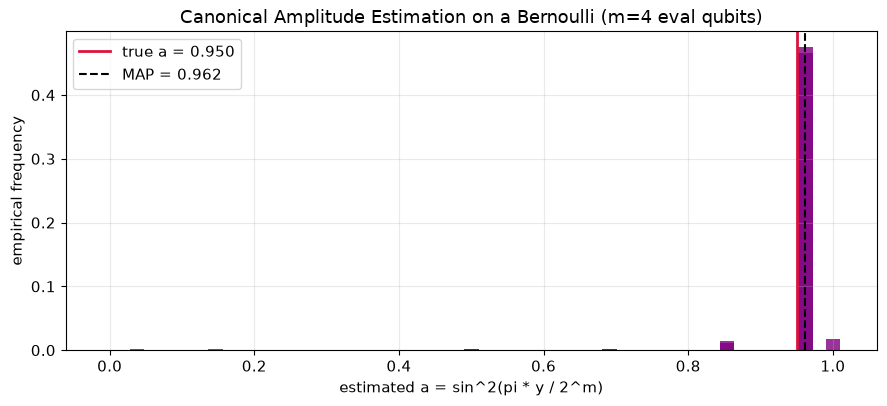

In [11]:
if not HAS_QISKIT:
    print("Qiskit not available — skip circuit demo.")
    print("Install with: pip install qiskit qiskit-aer")
else:
    from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister, transpile
    from qiskit_aer import AerSimulator
    from qiskit.circuit.library import GroverOperator

    a_target = a_true
    theta = 2 * np.arcsin(np.sqrt(a_target))

    # A: prepare sqrt(1-a)|0> + sqrt(a)|1>  on 1 qubit
    def make_A():
        qc = QuantumCircuit(1)
        qc.ry(theta, 0)
        return qc

    # Oracle marking |1>  (the "good" / success state)
    oracle = QuantumCircuit(1)
    oracle.z(0)

    A = make_A()
    Q = GroverOperator(oracle, state_preparation=A)

    # Canonical AE with m evaluation qubits (powers of Q)
    m = 4   # 2^m = 16 bins -> resolution ~ 1/16
    eval_q = QuantumRegister(m, "eval")
    obj_q = QuantumRegister(1, "obj")
    creg = ClassicalRegister(m, "c")
    qc = QuantumCircuit(eval_q, obj_q, creg)

    qc.compose(A, obj_q, inplace=True)
    qc.h(eval_q)

    for j in range(m):
        Q_pow = Q.power(2 ** j)
        controlled = Q_pow.control(1)
        qc.compose(controlled, [eval_q[j], obj_q[0]], inplace=True)

    # Inverse QFT on the evaluation register
    for j in range(m // 2):
        qc.swap(eval_q[j], eval_q[m - 1 - j])
    for j in range(m):
        qc.h(eval_q[j])
        for k in range(j + 1, m):
            qc.cp(-np.pi / 2 ** (k - j), eval_q[k], eval_q[j])

    qc.measure(eval_q, creg)

    sim = AerSimulator()
    tqc = transpile(qc, sim)
    result = sim.run(tqc, shots=2000).result()
    counts = result.get_counts()

    # Map bitstrings -> a estimates via sin^2(pi * y / 2^m)
    ests, weights = [], []
    for bitstr, cnt in counts.items():
        y = int(bitstr, 2)
        a_hat = np.sin(np.pi * y / (2 ** m)) ** 2
        ests.append(a_hat)
        weights.append(cnt)
    ests = np.array(ests)
    weights = np.array(weights, dtype=float)
    a_mean = np.average(ests, weights=weights)
    a_map = ests[np.argmax(weights)]

    print(f"Target a = {a_target:.4f}")
    print(f"Qiskit AE  mean estimate = {a_mean:.4f}")
    print(f"Qiskit AE  MAP estimate  = {a_map:.4f}")
    print(f"Circuit depth (transpiled) ≈ {tqc.depth()}, gates ≈ {len(tqc.data)}")

    fig, ax = plt.subplots(figsize=(9, 4.2))
    order = np.argsort(ests)
    ax.bar(ests[order], weights[order] / weights.sum(),
           width=0.02, color="purple", alpha=0.8)
    ax.axvline(a_target, color="crimson", lw=2, label=f"true a = {a_target:.3f}")
    ax.axvline(a_map, color="black", ls="--", lw=1.5, label=f"MAP = {a_map:.3f}")
    ax.set_xlabel("estimated a = sin^2(pi * y / 2^m)")
    ax.set_ylabel("empirical frequency")
    ax.set_title(f"Canonical Amplitude Estimation on a Bernoulli (m={m} eval qubits)")
    ax.legend()
    plt.tight_layout()
    plt.show()


## 10. Closing the loop — thesis-ready takeaways

| Step | Classical risk desk | Quantum-inspired version in this notebook |
|------|---------------------|-------------------------------------------|
| Scenarios | Monte Carlo P&L paths | Same toy portfolio (Gaussian factors) |
| VaR definition | Quantile of losses | Root of $a(\ell)=\alpha$ |
| Estimate $a(\ell)$ | Sample mean of indicators | Ideal QAE / optional Qiskit Bernoulli AE |
| Find the quantile | Sort / `np.quantile` | Binary search over $\ell$ calling AE |
| Complexity | $\sim 1/\sqrt{M}$ per CDF eval | $\sim 1/M$ (ideal) per CDF eval |

**What you should remember**

1. VaR is a **quantile**; every quantile is a level-set of a **CDF**; every CDF value
   is an **expectation of an indicator** — i.e. an amplitude.
2. Amplitude Estimation replaces the Monte Carlo estimate of that amplitude with a
   phase-estimation / Grover-based routine whose error scales as $1/M$.
3. The practical quantum-risk pipeline is therefore:
   **prepare scenarios → build a comparison oracle for threshold $\ell$ → QAE → search**.
4. This notebook used an *idealized* QAE noise model plus a tiny Bernoulli circuit.
   Building the comparison oracle for a real bank book (thousands of risk factors,
   path-dependent products) is the hard engineering — and the subject of the Goldman /
   JPMorgan resource-estimate papers in `../tesi/papers/L2B_risk/`.

### Ideas to explore next

- Replace Gaussian returns with Student-$t$ or historical bootstrap (fatter tails).
- Estimate **CVaR / Expected Shortfall** (average loss beyond VaR) — also an expectation,
  hence also QAE-friendly.
- Swap ideal QAE for Iterative AE / Maximum Likelihood AE (IQAE) and re-plot Section 6.
- Read `L2B_02_goldman_market_risk_2022` and `L0_04_brassard_qae_2002` tutorials side by side.
